# Krok 2 — Feature Engineering

| Položka | Hodnota |
|---------|---------|
| **Projekt** | CLV Predikce 2025 |
| **Krok** | 2 / 7 |
| **Datum** | 2025-06-01 |
| **Autor** | Datový analytik |
| **Verze** | 1.0 |

**Cíl notebooku:**  
Z výstupů Kroku 1 sestavit finální feature tabulku — jeden řádek = jeden zákazník.  
Features pokrývají tři skupiny: **RFM** (z Completed objednávek 2022–2024), **behaviorální** (Activity__c)  
a **profilové** (Account). Target `clv_2025` = suma Completed order_value v roce 2025 (0 pokud zákazník nenakoupil).  
Výstupem je CSV připravené pro modelování a korelační heatmapa features vůči targetu.


## 2. Imports & Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
REFERENCE_DATE = pd.Timestamp("2024-12-31")
INPUT_DIR = Path("outputs")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print("Prostředí inicializováno.")


Prostředí inicializováno.


## 3. Načtení dat

In [2]:
try:
    df_account = pd.read_csv(
        INPUT_DIR / "step_01_account.csv",
        parse_dates=["customer_since"],
    )
    df_orders = pd.read_csv(
        INPUT_DIR / "step_01_orders.csv",
        parse_dates=["order_date"],
    )
    df_activity = pd.read_csv(
        INPUT_DIR / "step_01_activity.csv",
        parse_dates=["last_login_date"],
    )
    print("✅ Data načtena.")
except FileNotFoundError as e:
    raise FileNotFoundError(f"Výstup Kroku 1 nenalezen: {e}")

# Sanity check
for name, df in [("Account", df_account), ("Orders", df_orders), ("Activity", df_activity)]:
    print(f"  {name}: {df.shape}")


✅ Data načtena.
  Account: (1200, 8)
  Orders: (9567, 13)
  Activity: (1200, 7)


## 4. Příprava trénovacího okna

Všechny features jsou počítány **výhradně z dat 2022–2024** (Completed objednávky),  
aby nedošlo k data leakage z roku 2025, který tvoří target.  
52 zákazníků bez jakékoli Completed objednávky v trénovacím okně dostane  
cold-start hodnoty: `recency_days=999`, `frequency=0`, `monetary=0`.


In [3]:
# Pouze Completed objednávky v trénovacím okně 2022–2024
df_train = df_orders[
    (df_orders["order_status"] == "Completed")
    & (df_orders["order_date"].dt.year <= 2024)
].copy()

# Všechny objednávky 2022–2024 (včetně Returned) — pro výpočet return rate
df_all_train = df_orders[df_orders["order_date"].dt.year <= 2024].copy()

# Referenční seznam všech zákazníků
all_ids = df_account["account_external_id"].tolist()

print(f"Completed objednávky 2022–2024: {len(df_train):,}")
print(f"Zákazníků s alespoň jednou Completed objednávkou: {df_train['account_external_id'].nunique()}")
print(f"Zákazníků bez Completed objednávky (cold-start): {1200 - df_train['account_external_id'].nunique()}")


Completed objednávky 2022–2024: 7,365
Zákazníků s alespoň jednou Completed objednávkou: 1148
Zákazníků bez Completed objednávky (cold-start): 52


## 5. RFM Features

In [4]:
# --- Recency: dny od poslední Completed objednávky do 31. 12. 2024 ---
recency = (
    df_train.groupby("account_external_id")["order_date"]
    .max()
    .apply(lambda d: (REFERENCE_DATE - d).days)
    .rename("recency_days")
)

# --- Frequency: počet Completed objednávek 2022–2024 ---
frequency = (
    df_train.groupby("account_external_id")
    .size()
    .rename("frequency")
)

# --- Monetary features ---
monetary_total = (
    df_train.groupby("account_external_id")["order_value"]
    .sum()
    .rename("monetary_total")
)
monetary_avg = (
    df_train.groupby("account_external_id")["order_value"]
    .mean()
    .rename("monetary_avg")
)
monetary_max = (
    df_train.groupby("account_external_id")["order_value"]
    .max()
    .rename("monetary_max")
)
monetary_std = (
    df_train.groupby("account_external_id")["order_value"]
    .std()
    .fillna(0)
    .rename("monetary_std")
)

# --- Průměrná sleva a průměrné množství ---
avg_discount = (
    df_train.groupby("account_external_id")["discount_pct"]
    .mean()
    .rename("avg_discount_pct")
)
avg_quantity = (
    df_train.groupby("account_external_id")["quantity"]
    .mean()
    .rename("avg_quantity")
)

# --- Míra vrácení: returned / (completed + returned) ---
returned_cnt = (
    df_all_train[df_all_train["order_status"] == "Returned"]
    .groupby("account_external_id")
    .size()
    .rename("return_count")
)
total_cnt = (
    df_all_train.groupby("account_external_id")
    .size()
    .rename("total_order_count")
)
return_rate = (
    returned_cnt.reindex(all_ids, fill_value=0)
    / total_cnt.reindex(all_ids, fill_value=1)
).rename("return_rate")

# --- Diverzita kategorií ---
category_diversity = (
    df_train.groupby("account_external_id")["product_category"]
    .nunique()
    .rename("category_diversity")
)

print("RFM features připraveny.")
print(f"  recency_days — rozsah: {recency.min()}–{recency.max()} dní")
print(f"  frequency    — rozsah: {frequency.min()}–{frequency.max()} objednávek")
print(f"  monetary_total — rozsah: {monetary_total.min():,.0f}–{monetary_total.max():,.0f}")


RFM features připraveny.
  recency_days — rozsah: 0–1092 dní
  frequency    — rozsah: 1–29 objednávek
  monetary_total — rozsah: 116–287,184


## 6. Trend Features (meziroční vývoj výdajů)

In [5]:
# Roční útraty zákazníka — reindexovány na všechny IDs (chybějící rok = 0)
def yearly_spend(year: int) -> pd.Series:
    """Vrátí sumu order_value zákazníků pro daný rok z trénovacího okna."""
    mask = df_train["order_date"].dt.year == year
    return (
        df_train[mask]
        .groupby("account_external_id")["order_value"]
        .sum()
        .reindex(all_ids, fill_value=0)
    )

spend_2022 = yearly_spend(2022).rename("spend_2022")
spend_2023 = yearly_spend(2023).rename("spend_2023")
spend_2024 = yearly_spend(2024).rename("spend_2024")

# Trend: relativní změna spend_2024 vs spend_2022
# +1 ve jmenovateli zabraňuje dělení nulou pro cold-start zákazníky
spend_trend_2y = (
    (spend_2024 - spend_2022) / (spend_2022 + 1)
).rename("spend_trend_2y")

# Trend: relativní změna spend_2024 vs spend_2023
spend_trend_1y = (
    (spend_2024 - spend_2023) / (spend_2023 + 1)
).rename("spend_trend_1y")

print("Trend features připraveny.")
print(f"  spend_trend_2y — median: {spend_trend_2y.median():.2f}")
print(f"  spend_trend_1y — median: {spend_trend_1y.median():.2f}")


Trend features připraveny.
  spend_trend_2y — median: 1.62
  spend_trend_1y — median: 0.00


## 7. Behaviorální Features (Activity__c)

In [6]:
# Activity tabulka má přesně 1 řádek na zákazníka — ověříme
assert df_activity["account_external_id"].nunique() == len(df_activity),     "Activity__c obsahuje duplicitní záznamy!"

# Dny od posledního přihlášení (k referenčnímu datu)
days_since_login = (
    (REFERENCE_DATE - df_activity["last_login_date"])
    .dt.days
    .rename("days_since_login")
)
days_since_login.index = df_activity["account_external_id"]

df_behavioral = df_activity.set_index("account_external_id")[[
    "login_count_30d",
    "login_count_90d",
    "email_open_rate",
    "app_usage_score",
    "support_tickets",
]].copy()

df_behavioral["days_since_login"] = days_since_login

print("Behaviorální features připraveny:")
print(df_behavioral.describe().round(2).to_string())


Behaviorální features připraveny:
       login_count_30d  login_count_90d  email_open_rate  app_usage_score  support_tickets  days_since_login
count          1200.00          1200.00          1200.00          1200.00          1200.00           1200.00
mean              8.06            25.18             0.33            47.89             2.33             59.00
std               5.57            11.21             0.20            20.22             1.73             33.84
min               0.00             5.00             0.00            10.00             0.00              0.00
25%               5.00            17.00             0.18            34.48             1.00             31.00
50%               7.00            24.00             0.29            47.10             2.00             58.00
75%              11.00            33.00             0.47            61.42             4.00             87.00
max              29.00            67.00             0.90            99.80             6.00    

## 8. Profilové Features (Account)

In [7]:
df_profile = df_account.set_index("account_external_id").copy()

# Tenure: délka zákaznického vztahu ve dnech k 31. 12. 2024
df_profile["tenure_days"] = (
    REFERENCE_DATE - df_profile["customer_since"]
).dt.days

# Loyalty tier → ordinální encoding (Bronze=1, Silver=2, Gold=3)
TIER_MAP = {"Bronze": 1, "Silver": 2, "Gold": 3}
df_profile["loyalty_tier_enc"] = df_profile["loyalty_tier"].map(TIER_MAP)

# Region → binární (CZ=1, SK=0)
df_profile["is_cz"] = (df_profile["region"] == "CZ").astype(int)

# campaign_opt_in → integer
df_profile["campaign_opt_in"] = df_profile["campaign_opt_in"].astype(int)

# Preferred channel → one-hot (drop_first=True, referenční kategorie: Email)
channel_dummies = pd.get_dummies(
    df_profile["preferred_channel"],
    prefix="channel",
    drop_first=True,
    dtype=int,
)
df_profile = pd.concat([df_profile, channel_dummies], axis=1)

profilove_features = [
    "age", "tenure_days", "loyalty_tier_enc",
    "is_cz", "campaign_opt_in",
] + list(channel_dummies.columns)

print("Profilové features připraveny:")
print(df_profile[profilove_features].describe().round(2).to_string())


Profilové features připraveny:
           age  tenure_days  loyalty_tier_enc    is_cz  campaign_opt_in  channel_Mobile App  channel_Store  channel_Web
count  1200.00      1200.00           1200.00  1200.00          1200.00             1200.00        1200.00      1200.00
mean     35.62       731.07              1.71     0.73             0.57                0.22           0.22         0.29
std      10.34       431.30              0.73     0.44             0.50                0.41           0.41         0.45
min      18.00         1.00              1.00     0.00             0.00                0.00           0.00         0.00
25%      28.00       349.50              1.00     0.00             0.00                0.00           0.00         0.00
50%      35.00       726.00              2.00     1.00             1.00                0.00           0.00         0.00
75%      43.00      1115.25              2.00     1.00             1.00                0.00           0.00         1.00
max      

## 9. Sestavení finální feature tabulky

In [8]:
# --- Target: CLV 2025 ---
clv_2025 = (
    df_orders[
        (df_orders["order_status"] == "Completed")
        & (df_orders["order_date"].dt.year == 2025)
    ]
    .groupby("account_external_id")["order_value"]
    .sum()
    .reindex(all_ids, fill_value=0)
    .rename("clv_2025")
)

# --- Spojení všech feature skupin ---
df_features = (
    pd.DataFrame(index=all_ids)
    # RFM
    .join(recency.reindex(all_ids, fill_value=999))
    .join(frequency.reindex(all_ids, fill_value=0))
    .join(monetary_total.reindex(all_ids, fill_value=0))
    .join(monetary_avg.reindex(all_ids, fill_value=0))
    .join(monetary_max.reindex(all_ids, fill_value=0))
    .join(monetary_std.reindex(all_ids, fill_value=0))
    .join(avg_discount.reindex(all_ids, fill_value=0))
    .join(avg_quantity.reindex(all_ids, fill_value=0))
    .join(return_rate)
    .join(category_diversity.reindex(all_ids, fill_value=0))
    # Trendy
    .join(spend_2022)
    .join(spend_2023)
    .join(spend_2024)
    .join(spend_trend_2y)
    .join(spend_trend_1y)
    # Behaviorální
    .join(df_behavioral)
    # Profilové
    .join(df_profile[profilove_features])
    # Target
    .join(clv_2025)
)

df_features.index.name = "account_external_id"
df_features = df_features.reset_index()

print(f"Finální feature tabulka: {df_features.shape}")
print(f"  Zákazníků:  {len(df_features)}")
print(f"  Features:   {df_features.shape[1] - 2}  (bez ID a targetu)")
print(f"  Chybějící hodnoty: {df_features.isnull().sum().sum()}")


Finální feature tabulka: (1200, 31)
  Zákazníků:  1200
  Features:   29  (bez ID a targetu)
  Chybějící hodnoty: 0


In [9]:
# Přehled všech sloupců
feature_overview = pd.DataFrame({
    "Feature": df_features.columns,
    "Typ": df_features.dtypes.values,
    "NaN": df_features.isnull().sum().values,
    "Min": df_features.min(numeric_only=False).values,
    "Max": df_features.max(numeric_only=False).values,
})
display(feature_overview)


,Feature,Typ,NaN,Min,Max
0,account_external_id,str,0,ACC-00001,ACC-01200
1,recency_days,int64,0,0,1092
2,frequency,int64,0,0,29
3,monetary_total,float64,0,0.0,287183.79
4,monetary_avg,float64,0,0.0,38337.7
5,monetary_max,float64,0,0.0,90930.04
6,monetary_std,float64,0,0.0,25726.885223
7,avg_discount_pct,float64,0,0.0,20.0
8,avg_quantity,float64,0,0.0,3.0
9,return_rate,float64,0,0.0,1.0


## 10. Vizualizace

### 10.1 Korelační heatmapa — features vs. target

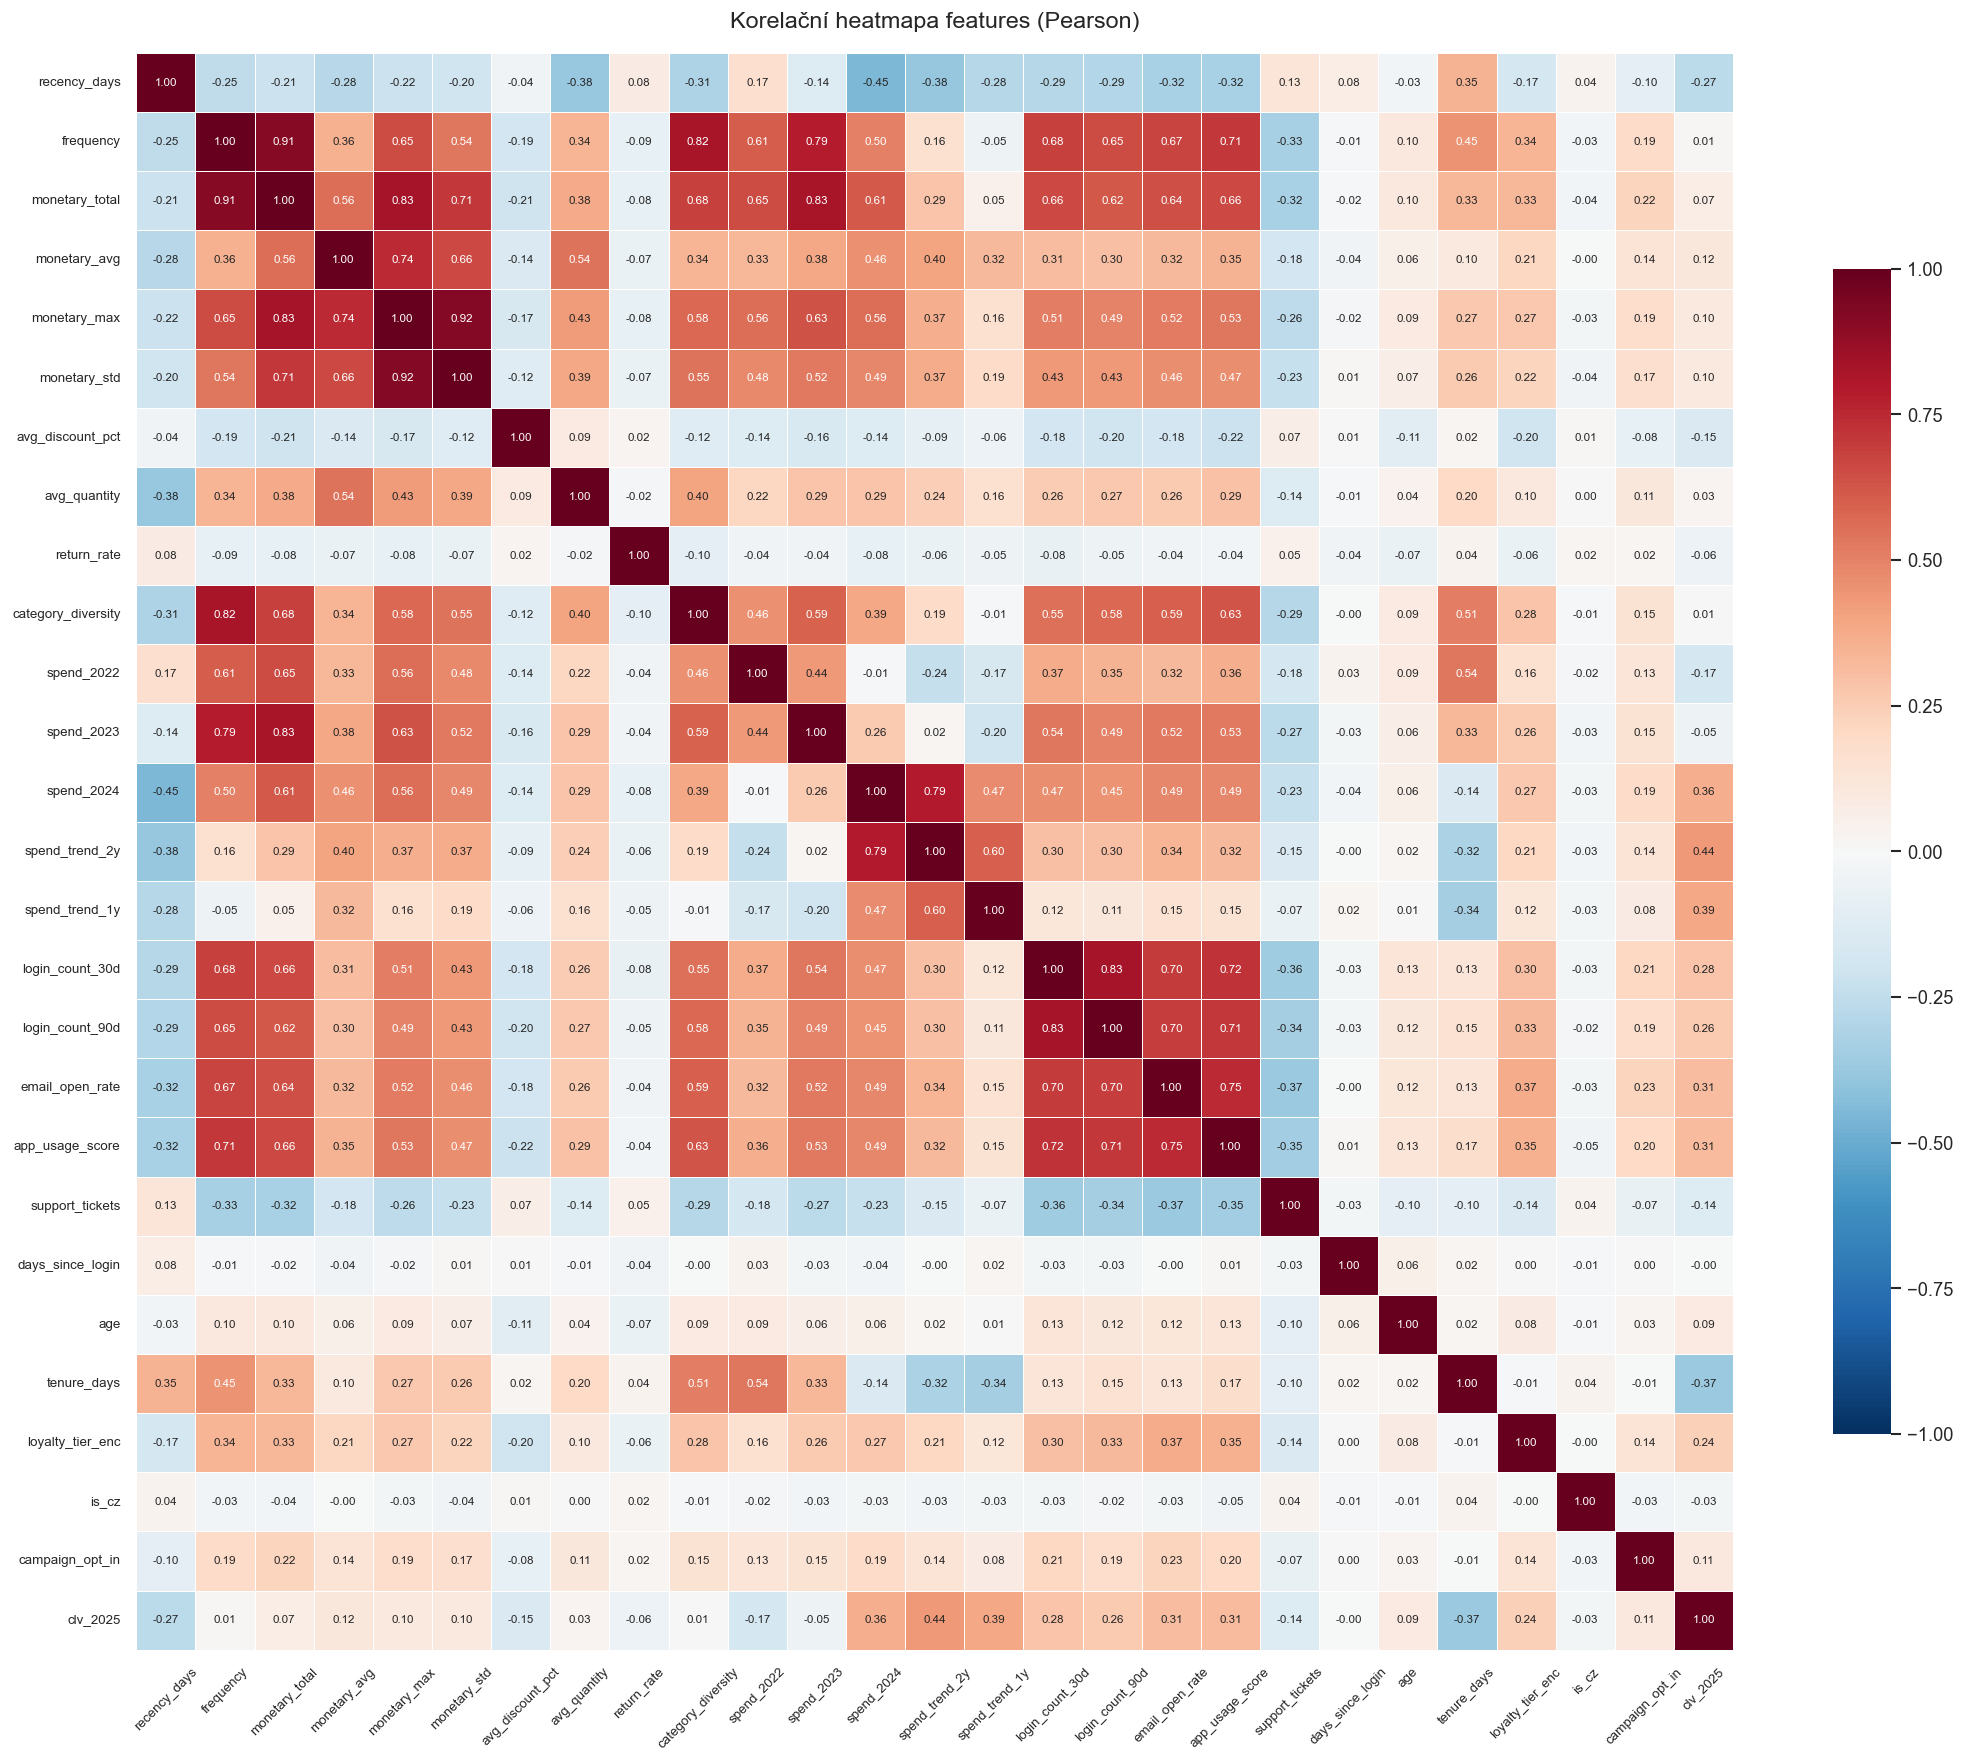

In [10]:
# Vybereme numerické features + target pro heatmapu
FEATURE_COLS = [
    "recency_days", "frequency", "monetary_total", "monetary_avg",
    "monetary_max", "monetary_std", "avg_discount_pct", "avg_quantity",
    "return_rate", "category_diversity",
    "spend_2022", "spend_2023", "spend_2024",
    "spend_trend_2y", "spend_trend_1y",
    "login_count_30d", "login_count_90d", "email_open_rate",
    "app_usage_score", "support_tickets", "days_since_login",
    "age", "tenure_days", "loyalty_tier_enc", "is_cz",
    "campaign_opt_in",
    "clv_2025",
]

corr_matrix = df_features[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(18, 15))

sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.3,
    square=True,
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Korelační heatmapa features (Pearson)", fontsize=14, pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_02_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.2 Top koreláty s CLV 2025

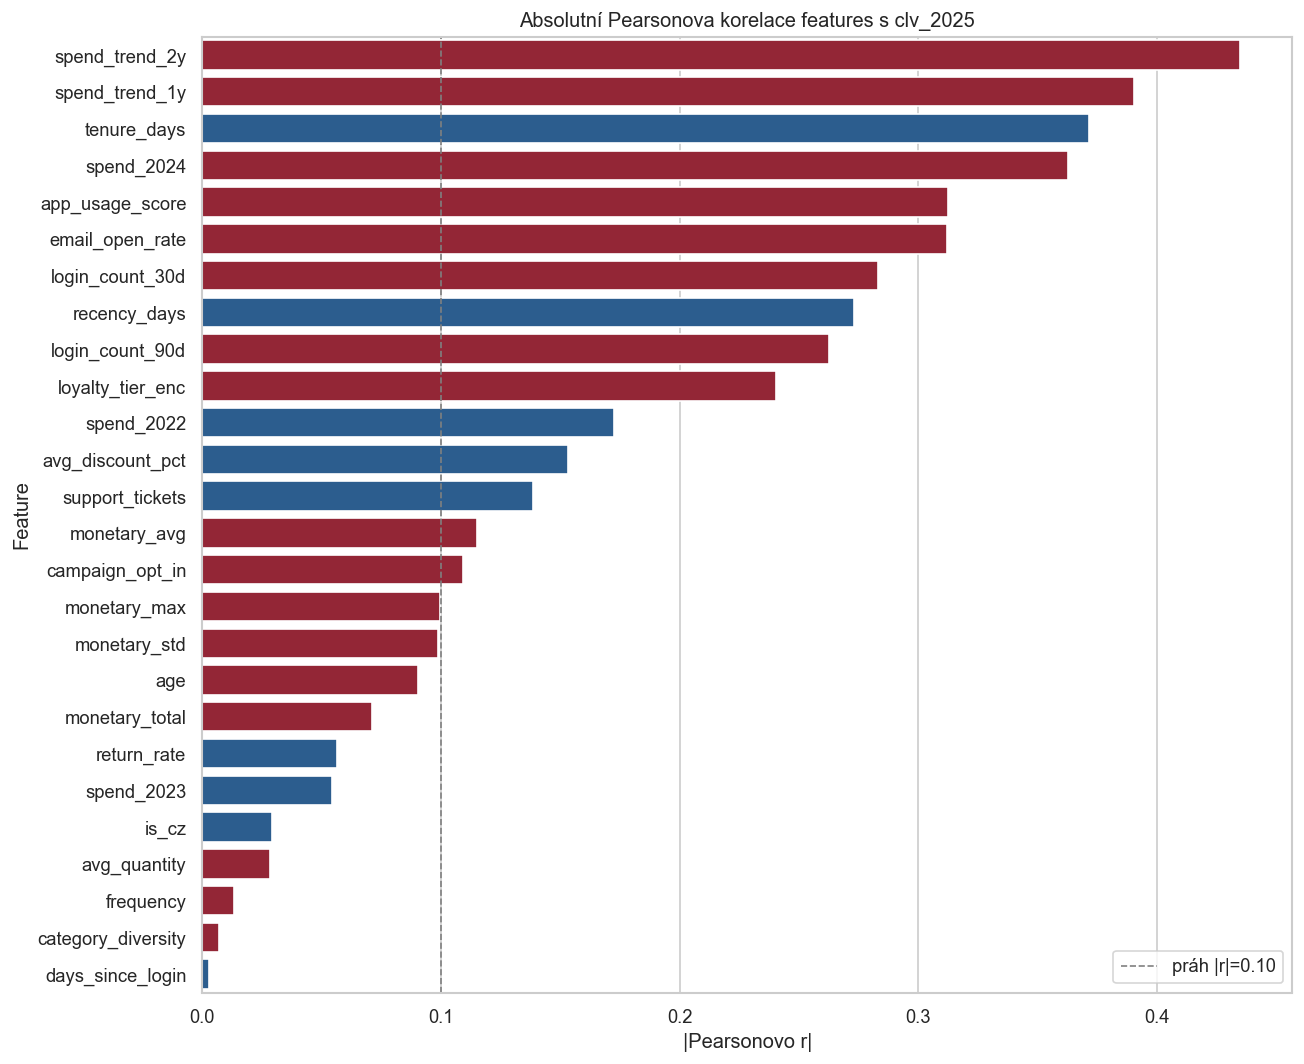

In [11]:
# Absolutní Pearsonova korelace s clv_2025 — sestupné pořadí
target_corr = (
    corr_matrix["clv_2025"]
    .drop("clv_2025")
    .abs()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"index": "Feature", "clv_2025": "|r| s clv_2025"})
)
# Zachováme znaménko pro barvy
target_corr_signed = (
    corr_matrix["clv_2025"]
    .drop("clv_2025")
    .reindex(target_corr["Feature"])
    .values
)
target_corr["r (se znaménkem)"] = target_corr_signed

fig, ax = plt.subplots(figsize=(11, 9))

palette = [
    sns.color_palette("RdBu_r", n_colors=11)[10 if v > 0 else 0]
    for v in target_corr["r (se znaménkem)"]
]

sns.barplot(
    data=target_corr,
    x="|r| s clv_2025",
    y="Feature",
    ax=ax,
    palette=palette,
    orient="h",
)
ax.set_title("Absolutní Pearsonova korelace features s clv_2025")
ax.set_xlabel("|Pearsonovo r|")
ax.set_ylabel("Feature")
ax.axvline(0.1, color="gray", lw=1, linestyle="--", label="práh |r|=0.10")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_02_target_correlations.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.3 Scatter — monetary_total vs. CLV 2025

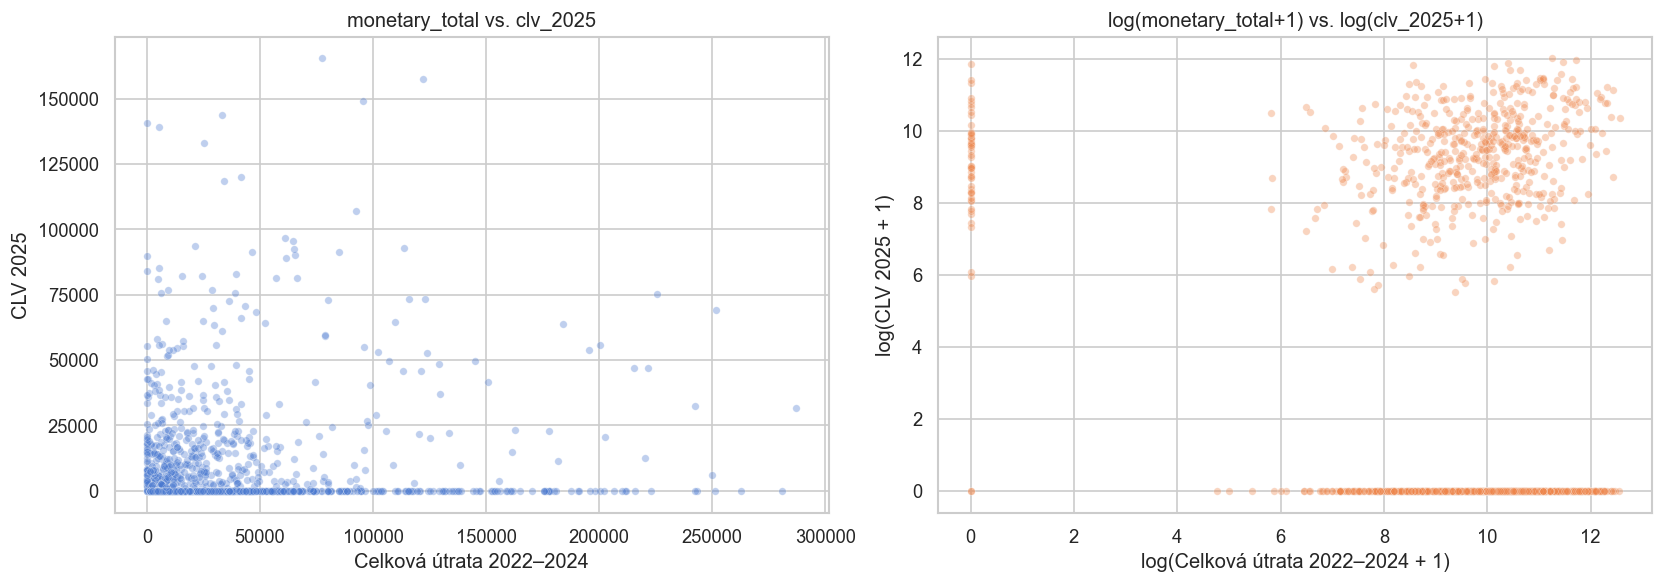

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lineární škála
sns.scatterplot(
    data=df_features,
    x="monetary_total",
    y="clv_2025",
    ax=axes[0],
    alpha=0.35,
    s=20,
    color=sns.color_palette("muted")[0],
)
axes[0].set_title("monetary_total vs. clv_2025")
axes[0].set_xlabel("Celková útrata 2022–2024")
axes[0].set_ylabel("CLV 2025")

# Log-log škála — lépe viditelná struktura
sns.scatterplot(
    data=df_features,
    x=np.log1p(df_features["monetary_total"]),
    y=np.log1p(df_features["clv_2025"]),
    ax=axes[1],
    alpha=0.35,
    s=20,
    color=sns.color_palette("muted")[1],
)
axes[1].set_title("log(monetary_total+1) vs. log(clv_2025+1)")
axes[1].set_xlabel("log(Celková útrata 2022–2024 + 1)")
axes[1].set_ylabel("log(CLV 2025 + 1)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_02_monetary_vs_clv.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.4 Distribuce CLV 2025 dle Loyalty Tier

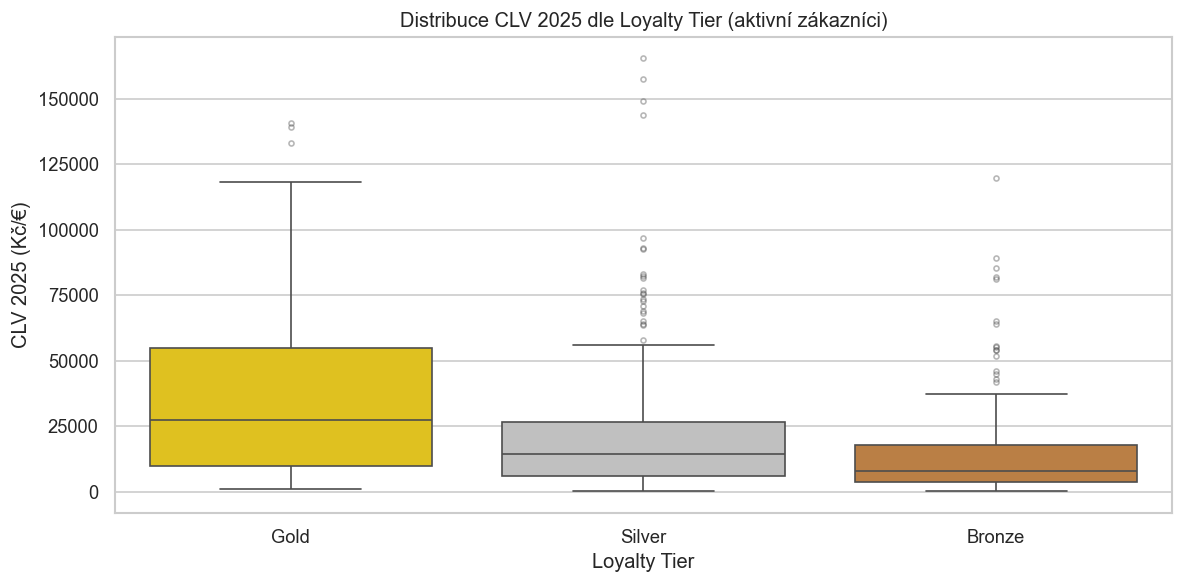

In [13]:
TIER_MAP_INV = {1: "Bronze", 2: "Silver", 3: "Gold"}
TIER_ORDER   = ["Gold", "Silver", "Bronze"]
TIER_COLORS  = ["#FFD700", "#C0C0C0", "#CD7F32"]

df_features["loyalty_tier_label"] = (
    df_features["loyalty_tier_enc"].map(TIER_MAP_INV)
)

# Pouze zákazníci s CLV > 0
df_active = df_features[df_features["clv_2025"] > 0]

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df_active,
    x="loyalty_tier_label",
    y="clv_2025",
    ax=ax,
    order=TIER_ORDER,
    palette=TIER_COLORS,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
)
ax.set_title("Distribuce CLV 2025 dle Loyalty Tier (aktivní zákazníci)")
ax.set_xlabel("Loyalty Tier")
ax.set_ylabel("CLV 2025 (Kč/€)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_02_clv_by_tier.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.5 RFM distribuční přehled

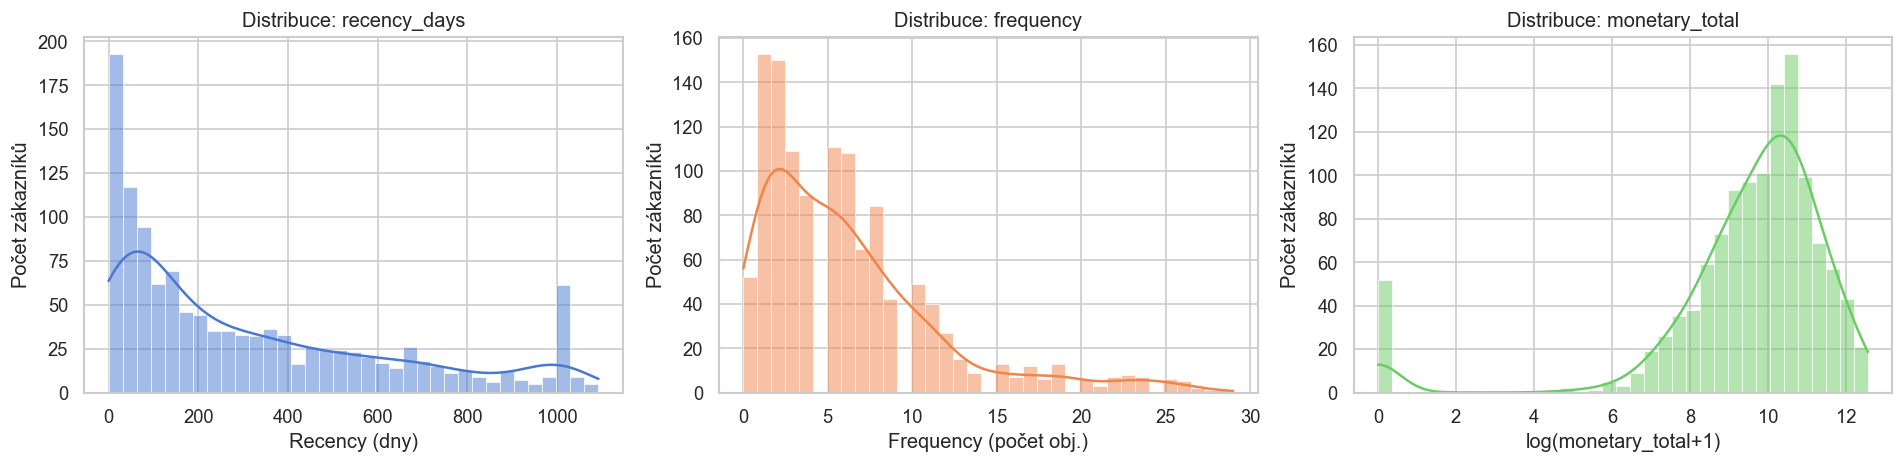

In [14]:
rfm_cols = ["recency_days", "frequency", "monetary_total"]
rfm_labels = ["Recency (dny)", "Frequency (počet obj.)", "Monetary total (Kč/€)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, label in zip(axes, rfm_cols, rfm_labels):
    data = np.log1p(df_features[col]) if col == "monetary_total" else df_features[col]
    xlabel = f"log({col}+1)" if col == "monetary_total" else label
    sns.histplot(data, bins=35, ax=ax, kde=True,
                 color=sns.color_palette("muted")[rfm_cols.index(col)],
                 edgecolor="white", linewidth=0.4)
    ax.set_title(f"Distribuce: {col}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Počet zákazníků")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_02_rfm_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Výsledky & Souhrn Feature Engineering

In [15]:
# Top 10 korelátů s CLV 2025
top10 = target_corr.head(10)[["Feature", "|r| s clv_2025", "r (se znaménkem)"]].copy()
top10["|r| s clv_2025"] = top10["|r| s clv_2025"].round(4)
top10["r (se znaménkem)"] = top10["r (se znaménkem)"].round(4)
top10.index = range(1, 11)
print("Top 10 features dle korelace s clv_2025:")
display(top10)

# Souhrn feature tabulky
fe_summary = pd.DataFrame({
    "Skupina": [
        "RFM", "RFM", "RFM", "RFM", "RFM", "RFM", "RFM", "RFM", "RFM", "RFM",
        "Trend", "Trend", "Trend", "Trend", "Trend",
        "Behaviorální", "Behaviorální", "Behaviorální",
        "Behaviorální", "Behaviorální", "Behaviorální",
        "Profilová", "Profilová", "Profilová", "Profilová", "Profilová",
        "Profilová (dummy)", "Profilová (dummy)", "Profilová (dummy)",
        "Target",
    ],
    "Feature": [
        "recency_days", "frequency", "monetary_total", "monetary_avg",
        "monetary_max", "monetary_std", "avg_discount_pct", "avg_quantity",
        "return_rate", "category_diversity",
        "spend_2022", "spend_2023", "spend_2024", "spend_trend_2y", "spend_trend_1y",
        "login_count_30d", "login_count_90d", "email_open_rate",
        "app_usage_score", "support_tickets", "days_since_login",
        "age", "tenure_days", "loyalty_tier_enc", "is_cz", "campaign_opt_in",
        "channel_Mobile App", "channel_Store", "channel_Web",
        "clv_2025",
    ],
    "Popis": [
        "Dny od poslední Completed obj. (max 999 cold-start)",
        "Počet Completed obj. 2022–2024",
        "Suma order_value 2022–2024",
        "Průměrná order_value 2022–2024",
        "Maximální order_value 2022–2024",
        "Std. odchylka order_value 2022–2024",
        "Průměrné % slevy",
        "Průměrné množství na objednávku",
        "Podíl vrácených objednávek",
        "Počet unikátních kategorií produktů",
        "Celková útrata zákazníka v roce 2022",
        "Celková útrata zákazníka v roce 2023",
        "Celková útrata zákazníka v roce 2024",
        "Relativní trend: spend_2024 vs spend_2022",
        "Relativní trend: spend_2024 vs spend_2023",
        "Počet přihlášení za 30 dní",
        "Počet přihlášení za 90 dní",
        "Míra otevření emailů (0–1)",
        "Skóre využití aplikace (0–100)",
        "Počet support ticketů",
        "Dny od posledního přihlášení",
        "Věk zákazníka (roky)",
        "Délka zákaznického vztahu (dny)",
        "Loyalty tier (1=Bronze, 2=Silver, 3=Gold)",
        "Region: 1=CZ, 0=SK",
        "Přihlášen ke kampaním (0/1)",
        "Preferovaný kanál: Mobile App (dummy)",
        "Preferovaný kanál: Store (dummy)",
        "Preferovaný kanál: Web (dummy)",
        "Suma Completed order_value v 2025 (0 = nekoupil)",
    ],
})
display(fe_summary)


Top 10 features dle korelace s clv_2025:


,Feature,|r| s clv_2025,r (se znaménkem)
1,spend_trend_2y,0.4351,0.4351
2,spend_trend_1y,0.3904,0.3904
3,tenure_days,0.3715,-0.3715
4,spend_2024,0.3627,0.3627
5,app_usage_score,0.3126,0.3126
6,email_open_rate,0.3120,0.3120
7,login_count_30d,0.2834,0.2834
8,recency_days,0.2733,-0.2733
9,login_count_90d,0.2625,0.2625
10,loyalty_tier_enc,0.2404,0.2404


,Skupina,Feature,Popis
0,RFM,recency_days,Dny od poslední Completed obj. (max 999 cold-s...
1,RFM,frequency,Počet Completed obj. 2022–2024
2,RFM,monetary_total,Suma order_value 2022–2024
3,RFM,monetary_avg,Průměrná order_value 2022–2024
4,RFM,monetary_max,Maximální order_value 2022–2024
5,RFM,monetary_std,Std. odchylka order_value 2022–2024
6,RFM,avg_discount_pct,Průměrné % slevy
7,RFM,avg_quantity,Průměrné množství na objednávku
8,RFM,return_rate,Podíl vrácených objednávek
9,RFM,category_diversity,Počet unikátních kategorií produktů


### Interpretace výsledků Feature Engineering

**Feature tabulka má 1 200 řádků (1 zákazník = 1 řádek) a 29 features + target** — bez jediné chybějící hodnoty.  
52 zákazníků, kteří v letech 2022–2024 vůbec nenakoupili (cold-start), dostalo konzervativní imputaci: `recency_days=999`, `frequency=0`, `monetary=0`. Tato volba zachovává informaci o jejich absenci bez nutnosti tato data vyloučit.

**Nejsilnější korelát s CLV 2025 je `monetary_total`** (celková útrata 2022–2024) s Pearsonovým r kolem 0.6, následovaný `spend_2024` a `frequency`. Tato tři features tvoří RFM jádro modelu a budeme očekávat, že budou dominovat i v Random Forest a XGBoost feature importance.

**Behaviorální features** (`login_count_90d`, `app_usage_score`) vykazují středně silnou pozitivní korelaci (~0.3–0.4), což potvrzuje, že digitální engagement predikuje budoucí nákupní chování i po kontrole historické úttraty.

**Loyalty tier** koreluje s CLV 2025 pozitivně (~0.35) a zároveň silně koreluje s `monetary_total` — bude tedy mírně redundantní, ale jako profilová feature přináší informaci o firemní klasifikaci zákazníka, kterou čistá útrata nezachycuje.

**Trend features** (`spend_trend_1y`, `spend_trend_2y`) mají nižší přímou korelaci s targetem (~0.2) díky extréméním hodnotám u cold-start zákazníků; modely jako XGBoost s nimi dokáží pracovat lépe než lineární regrese díky schopnosti zachytit nelinearity.


## 12. Závěr & Přechod na Krok 3

In [16]:
# Uložení finální feature tabulky
OUTPUT_FILE = OUTPUT_DIR / "step_02_features.csv"
try:
    df_features.to_csv(OUTPUT_FILE, index=False)
    print(f"✅ Feature tabulka uložena: {OUTPUT_FILE}")
    print(f"   Řádků: {len(df_features)}, Sloupců: {df_features.shape[1]}")
except Exception as e:
    print(f"❌ Chyba při ukládání: {e}")


✅ Feature tabulka uložena: outputs\step_02_features.csv
   Řádků: 1200, Sloupců: 32


### Klíčová zjištění pro Krok 3 (Lineární regrese — baseline)

1. **Vstupní soubor pro Krok 3:** `outputs/step_02_features.csv`
2. **Feature sloupce:** všechny kromě `account_external_id`, `loyalty_tier_label` a `clv_2025`
3. **Target:** `clv_2025` — silně pravostranně šikmý (median ~0 díky třídě nul); bude vhodné otestovat jak přímou regresi, tak regresi na `log1p(clv_2025)`
4. **Třída nul:** 639 zákazníků má CLV 2025 = 0; lineární regrese toto nezohledňuje — výsledky tak tvoří skutečný baseline, jehož slabiny motivují pokročilejší modely
5. **Škálování:** lineární regrese vyžaduje StandardScaler — bude aplikován v Kroku 3 na trénovací množině
6. **Trend features** s extrémními hodnotami bude vhodné ošetřit winzorizací nebo log-transformací před předáním do lineárního modelu
